# Behavioural + identity feature redundancy & relevance audit
Scope: sender **behavioural** features (volume, fan-out, repeat-content, diversity ratios, velocity z-score, sender age, SIM-farming IMSI) and **identity-lens** signal. Content flags and raw message fields (`dcs`, `text_length`, `text_decode_failed`) are deliberately excluded. FAISS near-dup features are off by default (`INCLUDE_NEAR_DUP`).

Identity note: `entropy_level` / `entropy_residual_spread` exist only in the Feast snapshot, not per message in the CSVs, so `text_entropy` (message-level Shannon entropy, the input to that baseline) stands in for the identity lens. It is not a model feature today.

Spearman pairwise redundancy (|rho| >= 0.9), boundedness-artifact checks, and feature-vs-label relevance.
Reuses `scripts/analyze_feature_redundancy.py` (which reuses the real `_base_feature_frame` / `build_combined_frame`), so numbers match the script.

**Cautions built in:** low label correlation != useless (interactions); the SMPP label is ~= `has_url`; the CDR sample spans ~2 days so age buckets are near-complementary by construction.

Set `SOURCE` below and re-run from the top.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "scripts").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from IPython.display import display

from scripts.analyze_feature_redundancy import (
    load_sample, build_features, redundant_pairs, clusters, spearman,
    boundedness_check, label_relevance, BOUNDED, STRATA_COL,
)
from models.anomaly.data import BEHAVIORAL_COLS, IMSI_DISTINCT_ORIG_COL, SENDER_VELOCITY_ZSCORE_COL, NEAR_DUP_COLS

SOURCE = "SS7"          # "SS7" or "SMPP"
THRESH = 0.9
INCLUDE_NEAR_DUP = False   # FAISS near-dup features (campaign-level, not sender-level)
CACHE = ROOT / "data/processed/feature_analysis"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})

## 1. Load (cached sample; rebuilds from the CSVs if missing)

In [2]:
fp, mp = CACHE / f"features_{SOURCE}.parquet", CACHE / f"meta_{SOURCE}.parquet"
if not fp.exists():
    CACHE.mkdir(parents=True, exist_ok=True)
    pu, pe = (0.10, 0.15) if SOURCE == "SS7" else (0.05, 1.0)
    raw = load_sample(SOURCE, ROOT / "data/processed", pu, pe)
    X = build_features(raw); X.to_parquet(fp)
    raw[["rule_evaluated", "rule_flagged", "in_uniform", "originator"]].to_parquet(mp)
X, M = pd.read_parquet(fp), pd.read_parquet(mp)
BEH = (BEHAVIORAL_COLS + [IMSI_DISTINCT_ORIG_COL, IMSI_DISTINCT_ORIG_COL + "_known",
       SENDER_VELOCITY_ZSCORE_COL, SENDER_VELOCITY_ZSCORE_COL + "_known",
       "sender_recipient_diversity_ratio_5min_known", "sender_recipient_diversity_ratio_1hr_known",
       "gated_diversity_5min", "gated_diversity_1hr"]
       + [c for c in X.columns if c.startswith("sender_age_bucket_")])
IDENT = ["text_entropy"]
KEEP = [c for c in BEH + IDENT + (NEAR_DUP_COLS if INCLUDE_NEAR_DUP else []) if c in X.columns]
X = X[KEEP]
uni = X[M["in_uniform"].to_numpy()]                      # uniform traffic sample -> redundancy
lab_mask = M["rule_evaluated"].to_numpy()
lab, y = X[lab_mask].reset_index(drop=True), M.loc[lab_mask, "rule_flagged"].astype(float).reset_index(drop=True)
print(f"{SOURCE}: {len(X):,} rows | uniform {len(uni):,} | labelled {len(lab):,} (pos rate {y.mean():.4f})")
dead = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
print("constant/dead columns:", dead)

SS7: 632,576 rows | uniform 274,429 | labelled 623,958 (pos rate 0.1079)


constant/dead columns: ['sender_age_bucket_7day_to_30day', 'sender_age_bucket_gte_30day']


## 2. Coverage / missingness

In [3]:
print("nonnull fraction < 1:"); print(X.notna().mean()[lambda s: s < 1].round(3).to_string())
print(); print(uni.describe(percentiles=[.5, .99]).T[["min", "50%", "99%", "max"]].round(3).to_string())

nonnull fraction < 1:
imsi_distinct_originators_1hr    0.692
sender_velocity_zscore_5min      0.999
text_entropy                     0.999



                                               min       50%        99%        max
sender_msgs_last_5min                        0.000   596.000   1751.000   2272.000
sender_msgs_last_1hr                         0.000  7097.000  18444.000  21648.000
sender_unique_destinations_1hr               0.000     1.000      8.000      9.000
sender_repeat_content_ratio_1hr              0.000     0.000      0.284      1.000
sender_age_days                              0.000     1.250      1.974      2.000
sender_recipient_diversity_ratio_5min        0.000     0.002      0.231      1.000
sender_recipient_diversity_ratio_1hr         0.000     0.000      0.026      1.000
imsi_distinct_originators_1hr                0.000     1.000      2.000      4.000
imsi_distinct_originators_1hr_known          0.000     1.000      1.000      1.000
sender_velocity_zscore_5min                 -2.877     0.549      3.447      7.216
sender_velocity_zscore_5min_known            0.000     1.000      1.000      1.000
send

## 3. Spearman heatmap (hierarchically ordered)
Non-constant features only. Ordering groups redundant features into visible blocks.

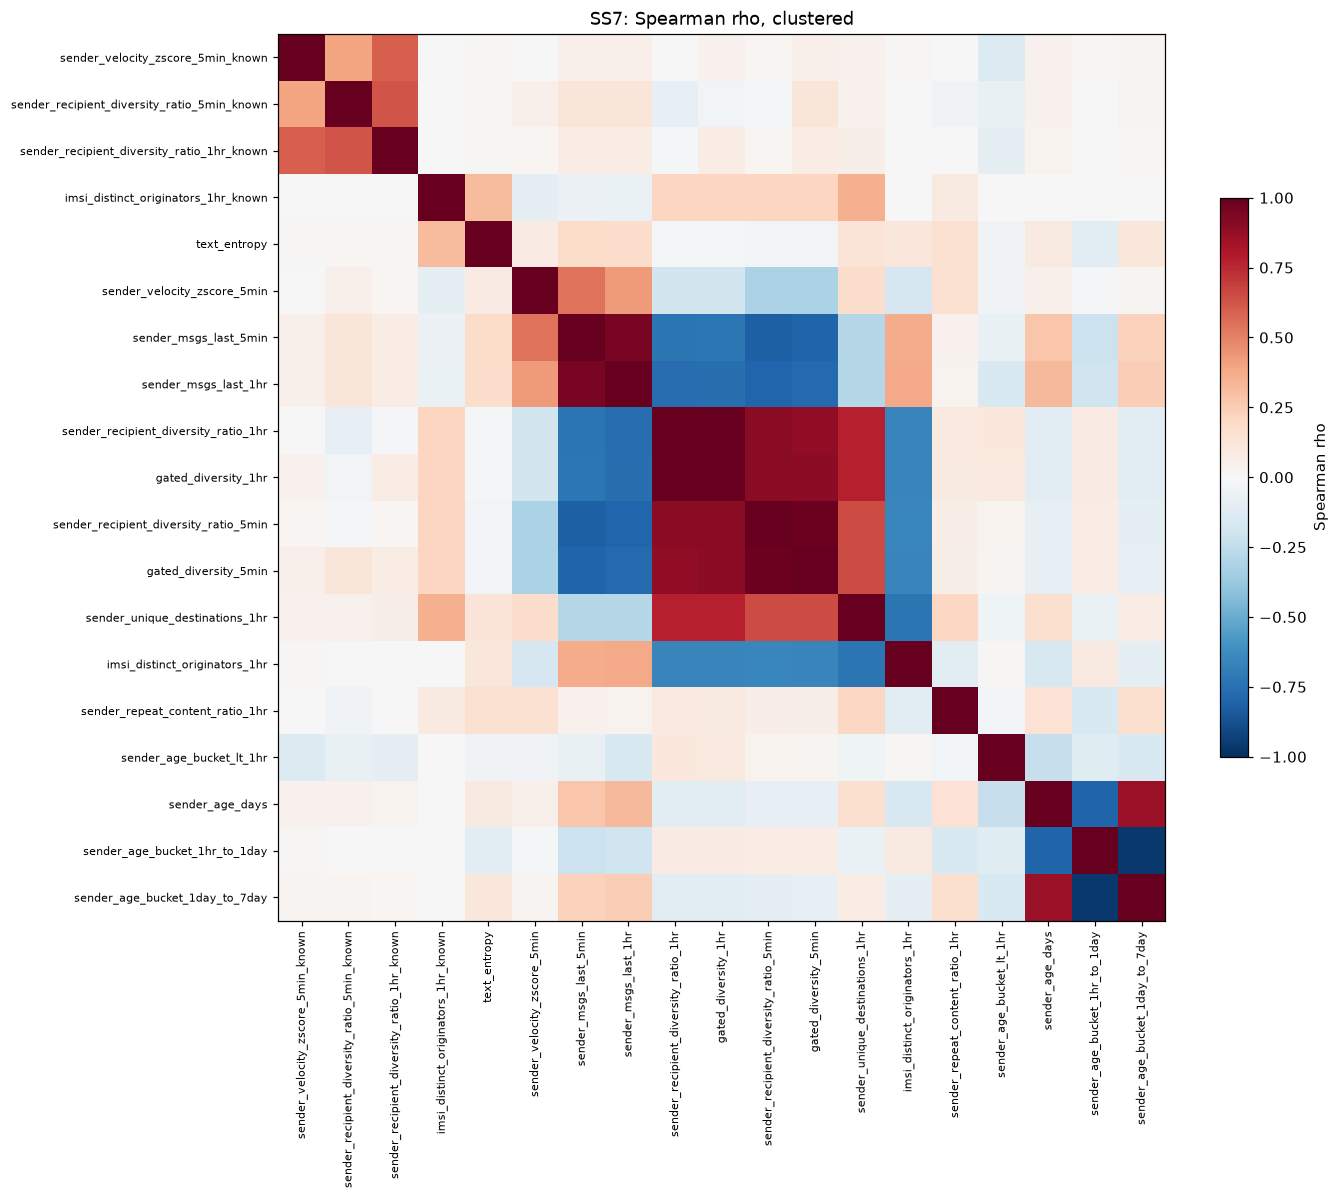

In [4]:
cols = [c for c in uni.columns if c not in dead]
corr = uni[cols].corr(method="spearman").fillna(0)
dist = squareform(1 - corr.abs().to_numpy(), checks=False)
order = hierarchy.leaves_list(hierarchy.linkage(dist, "average"))
oc = [cols[i] for i in order]
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.loc[oc, oc], cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(oc))); ax.set_xticklabels(oc, rotation=90, fontsize=7)
ax.set_yticks(range(len(oc))); ax.set_yticklabels(oc, fontsize=7); ax.grid(False)
fig.colorbar(im, shrink=.6, label="Spearman rho"); ax.set_title(f"{SOURCE}: Spearman rho, clustered"); plt.show()

## 4. Pairs above threshold + redundancy clusters

In [5]:
corr_raw = uni[cols].corr(method="spearman")
pairs = redundant_pairs(corr_raw, THRESH)
display(pairs)
print("clusters:", clusters(pairs, cols))
watch = redundant_pairs(corr_raw, 0.8); display(watch[watch.rho.abs() < THRESH])

,a,b,rho
4,sender_recipient_diversity_ratio_1hr,gated_diversity_1hr,0.993302
2,sender_recipient_diversity_ratio_5min,gated_diversity_5min,0.983983
5,sender_age_bucket_1hr_to_1day,sender_age_bucket_1day_to_7day,-0.963116
0,sender_msgs_last_5min,sender_msgs_last_1hr,0.951277
1,sender_recipient_diversity_ratio_5min,sender_recipient_diversity_ratio_1hr,0.904488
3,sender_recipient_diversity_ratio_5min,gated_diversity_1hr,0.902687


clusters: [['sender_msgs_last_5min', 'sender_msgs_last_1hr'], ['sender_recipient_diversity_ratio_5min', 'sender_recipient_diversity_ratio_1hr', 'gated_diversity_5min', 'gated_diversity_1hr'], ['sender_age_bucket_1hr_to_1day', 'sender_age_bucket_1day_to_7day']]


,a,b,rho
10,gated_diversity_5min,gated_diversity_1hr,0.895194
8,sender_recipient_diversity_ratio_1hr,gated_diversity_5min,0.888515
4,sender_age_days,sender_age_bucket_1day_to_7day,0.860111
1,sender_msgs_last_5min,sender_recipient_diversity_ratio_5min,-0.818847
2,sender_msgs_last_5min,gated_diversity_5min,-0.802850
3,sender_age_days,sender_age_bucket_1hr_to_1day,-0.801019


## 5. Pair explorer
Pick any two features: rank-space density (mass points show as bright edges), Spearman overall vs interior-only vs within message-count strata.

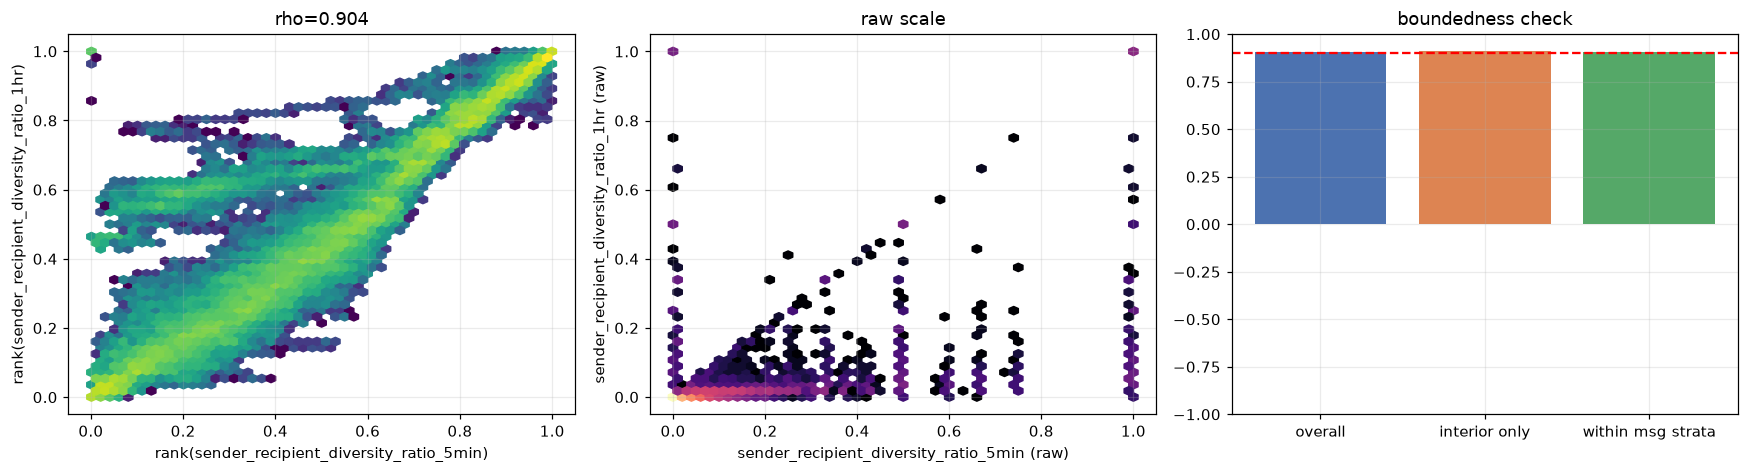

{'a': 'sender_recipient_diversity_ratio_5min', 'b': 'sender_recipient_diversity_ratio_1hr', 'frac_at_bound_a': np.float64(0.0041), 'frac_at_bound_b': np.float64(0.0015), 'interior_rows': 273301, 'rho_interior': np.float64(0.912), 'rho_within_msg_strata': np.float64(0.9044), 'holds_up': True}


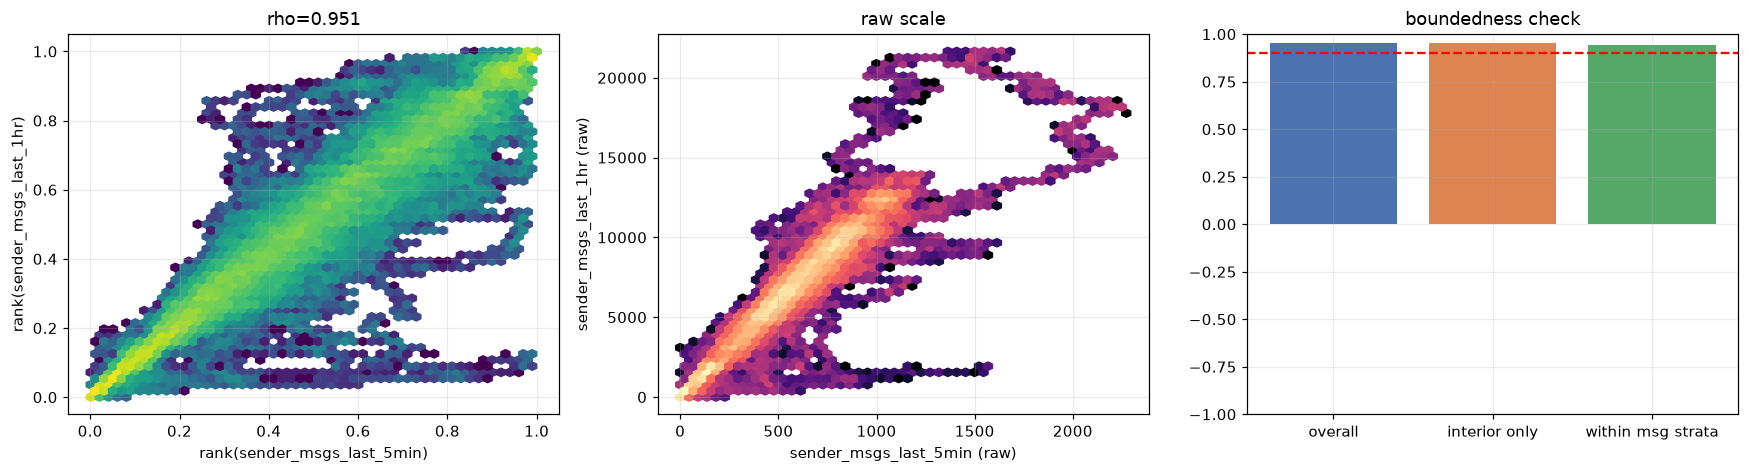

{'a': 'sender_msgs_last_5min', 'b': 'sender_msgs_last_1hr', 'frac_at_bound_a': np.float64(0.0023), 'frac_at_bound_b': np.float64(0.0008), 'interior_rows': 274429, 'rho_interior': np.float64(0.9513), 'rho_within_msg_strata': np.float64(0.9442), 'holds_up': True}


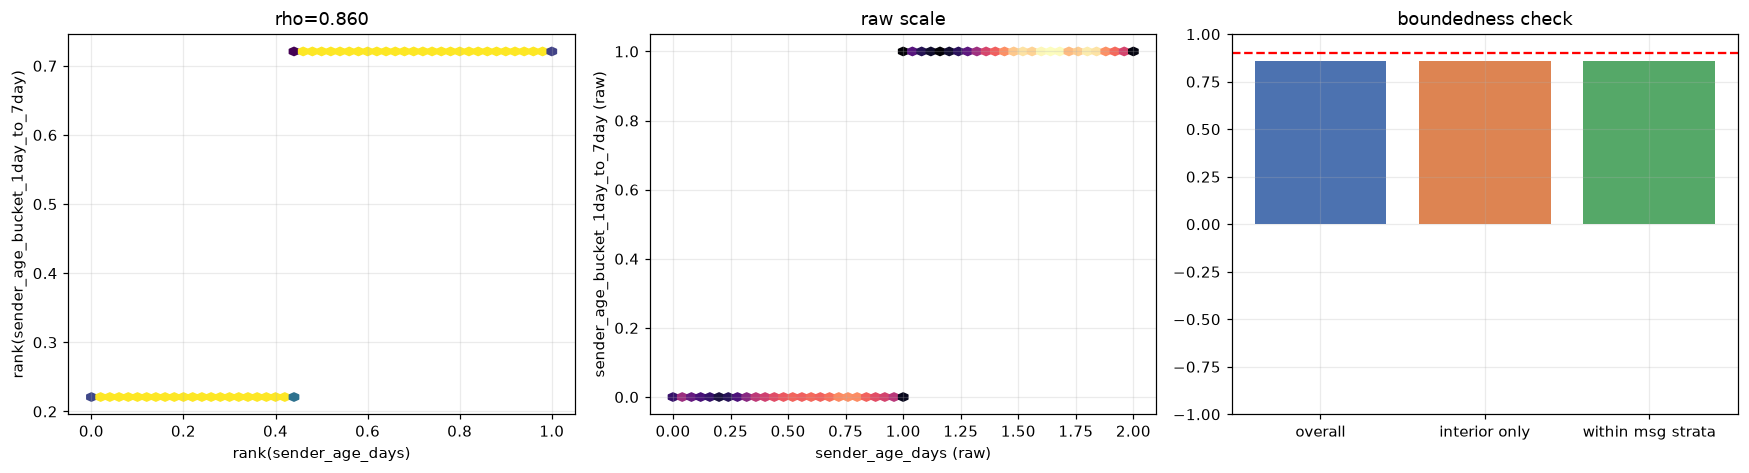

{'a': 'sender_age_days', 'b': 'sender_age_bucket_1day_to_7day', 'frac_at_bound_a': np.float64(0.0003), 'frac_at_bound_b': np.float64(1.0), 'interior_rows': 274429, 'rho_interior': np.float64(0.8601), 'rho_within_msg_strata': np.float64(0.8595), 'holds_up': False}


In [6]:
def pair_view(a, b):
    ok = uni[a].notna() & uni[b].notna()
    ra, rb = uni.loc[ok, a].rank(pct=True), uni.loc[ok, b].rank(pct=True)
    fig, axs = plt.subplots(1, 3, figsize=(16, 4.4))
    axs[0].hexbin(ra, rb, gridsize=50, bins="log", cmap="viridis", mincnt=1)
    axs[0].set(xlabel=f"rank({a})", ylabel=f"rank({b})", title=f"rho={spearman(uni[a], uni[b]):.3f}")
    axs[1].hexbin(uni.loc[ok, a], uni.loc[ok, b], gridsize=50, bins="log", cmap="magma", mincnt=1)
    axs[1].set(xlabel=f"{a} (raw)", ylabel=f"{b} (raw)", title="raw scale")
    bc = boundedness_check(uni, a, b, THRESH)
    labels = ["overall", "interior only", "within msg strata"]
    vals = [spearman(uni[a], uni[b]), bc["rho_interior"], bc["rho_within_msg_strata"]]
    axs[2].bar(labels, vals, color=["#4c72b0", "#dd8452", "#55a868"]); axs[2].axhline(THRESH, c="r", ls="--")
    axs[2].set_ylim(-1, 1); axs[2].set_title("boundedness check"); plt.tight_layout(); plt.show()
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in bc.items()})

# edit these names to explore any pair (names = columns of `cols`)
for a_, b_ in [("sender_recipient_diversity_ratio_5min", "sender_recipient_diversity_ratio_1hr"),
               ("sender_msgs_last_5min", "sender_msgs_last_1hr"),
               ("sender_age_days", "sender_age_bucket_1day_to_7day")]:
    pair_view(a_, b_)

## 6. Boundedness table for every flagged pair involving a bounded feature

In [7]:
bc = pd.DataFrame([boundedness_check(uni, r.a, r.b, THRESH) for r in pairs.itertuples() if r.a in BOUNDED or r.b in BOUNDED])
display(bc)
print("holds_up=False => correlation was a boundedness/mass-point artifact: do NOT drop.")

,a,b,frac_at_bound_a,frac_at_bound_b,interior_rows,rho_interior,rho_within_msg_strata,holds_up
0,sender_recipient_diversity_ratio_1hr,gated_diversity_1hr,0.001527,0.001975,273887,1.000000,1.000000,True
1,sender_recipient_diversity_ratio_5min,gated_diversity_5min,0.004110,0.005083,273034,1.000000,0.993367,True
2,sender_recipient_diversity_ratio_5min,sender_recipient_diversity_ratio_1hr,0.004110,0.001527,273301,0.911961,0.904424,True
3,sender_recipient_diversity_ratio_5min,gated_diversity_1hr,0.004110,0.001975,273235,0.911897,0.905060,True


holds_up=False => correlation was a boundedness/mass-point artifact: do NOT drop.


## 7. Label relevance (rough signal only)
Marginal association misses interactions - compare against model-based importance in section 9.

,feature,spearman_y,roc_auc,auc_dist_from_half,mutual_info,pos_rate_if_1_over_if_0,nonnull_frac,n_unique
3,sender_repeat_content_ratio_1hr,0.2111,0.6755,0.1755,0.0317,NaN,1.0000,174679
7,imsi_distinct_originators_1hr,0.1211,0.5902,0.0902,0.0122,NaN,0.6921,5
8,imsi_distinct_originators_1hr_known,0.1073,0.5798,0.0798,0.0064,2.2436,1.0000,2
9,sender_velocity_zscore_5min,-0.0658,0.4388,0.0612,0.0029,NaN,0.9992,622486
2,sender_unique_destinations_1hr,-0.0636,0.4485,0.0515,0.0069,NaN,1.0000,10
20,text_entropy,0.0502,0.5467,0.0467,0.0273,NaN,0.9994,107106
13,gated_diversity_5min,-0.0373,0.4653,0.0347,0.0051,NaN,1.0000,7077
5,sender_recipient_diversity_ratio_5min,-0.0372,0.4654,0.0346,0.0050,NaN,1.0000,7077
14,gated_diversity_1hr,-0.0372,0.4654,0.0346,0.0057,NaN,1.0000,50222
6,sender_recipient_diversity_ratio_1hr,-0.0357,0.4668,0.0332,0.0058,NaN,1.0000,50222


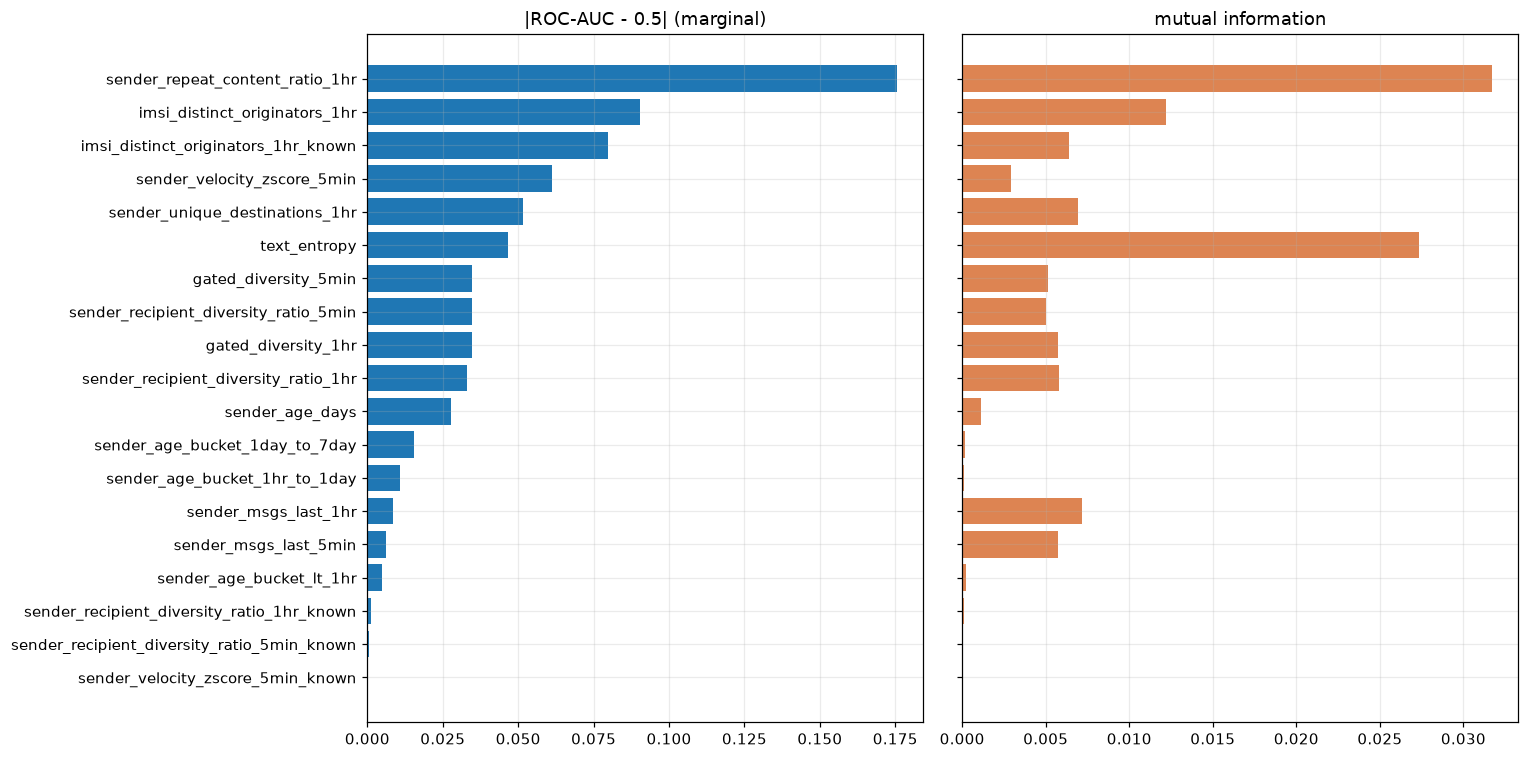

In [8]:
if y.nunique() < 2:
    print("single-class pool: label relevance undefined")
else:
    rel = label_relevance(lab, y); display(rel.round(4))
    top = rel.dropna(subset=["auc_dist_from_half"]).head(25)[::-1]
    fig, axs = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
    axs[0].barh(top.feature, top.auc_dist_from_half); axs[0].set_title("|ROC-AUC - 0.5| (marginal)")
    axs[1].barh(top.feature, top.mutual_info, color="#dd8452"); axs[1].set_title("mutual information")
    plt.tight_layout(); plt.show()

## 8. Single feature vs label
Binned positive rate (quantile bins; low-cardinality features shown per value). Non-monotonic shapes here are exactly what Spearman/AUC understate.

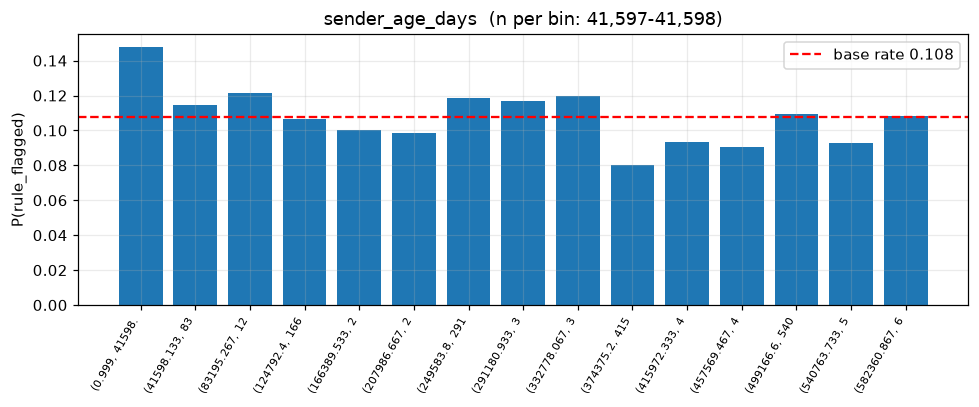

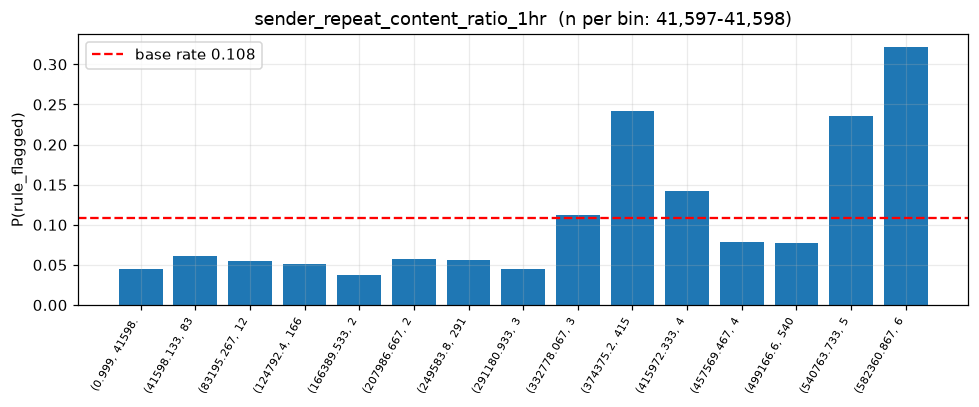

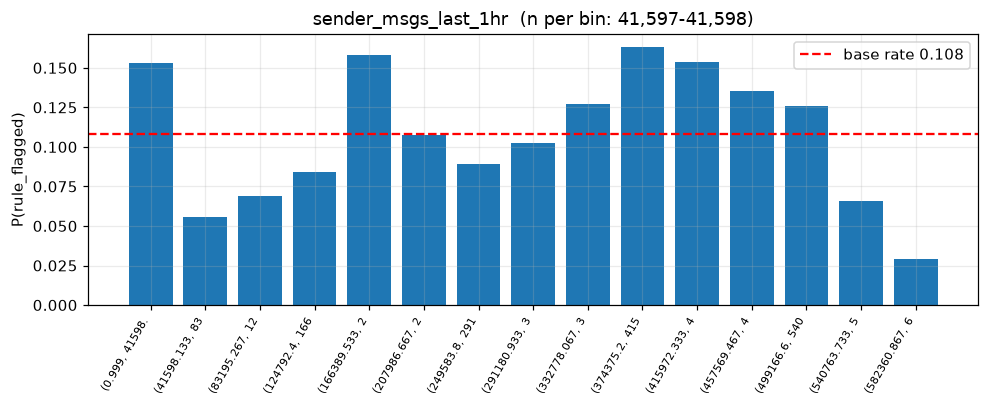

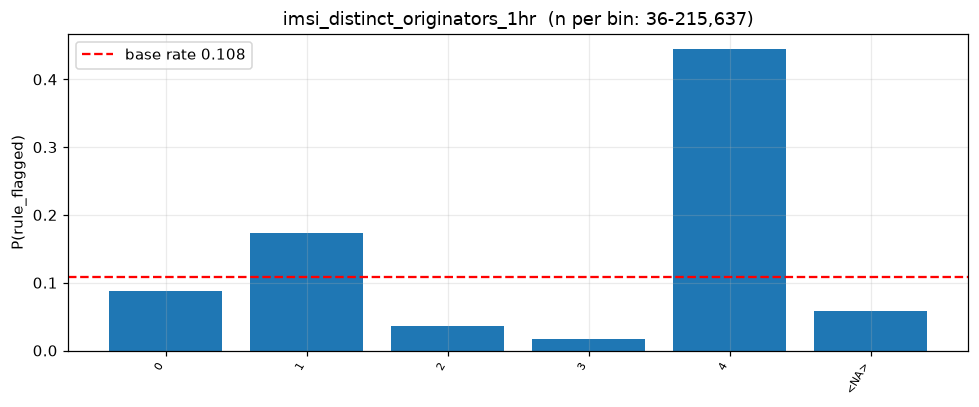

In [9]:
def feature_vs_label(f, bins=15):
    s = lab[f]
    b = s.astype("Int64").astype(str) if s.nunique() <= 12 else pd.qcut(s.rank(method="first"), bins, duplicates="drop")
    g = pd.DataFrame({"b": b, "y": y}).groupby("b", observed=True)["y"].agg(["mean", "size"])
    fig, ax = plt.subplots(figsize=(9, 3.8)); ax.bar(range(len(g)), g["mean"])
    ax.axhline(y.mean(), c="r", ls="--", label=f"base rate {y.mean():.3f}")
    ax.set_xticks(range(len(g))); ax.set_xticklabels([str(i)[:14] for i in g.index], rotation=60, ha="right", fontsize=7)
    ax.set(ylabel="P(rule_flagged)", title=f"{f}  (n per bin: {g['size'].min():,}-{g['size'].max():,})"); ax.legend(); plt.tight_layout(); plt.show()
for f_ in ["sender_age_days", "sender_repeat_content_ratio_1hr", "sender_msgs_last_1hr", "imsi_distinct_originators_1hr"]:   # edit to explore
    feature_vs_label(f_)

## 9. Model-based check: gain vs permutation vs marginal (LightGBM, originator-grouped split)
Behavioural-only LightGBM (no content flags/raw fields, so PR-AUC here is NOT the production model's; read importances relatively). Gain that isn't matched by permutation drop suggests memorisation (e.g. `imsi_distinct_originators_1hr`). Takes ~1 min.

holdout PR-AUC 0.3462


,gain_share,perm_drop_prAUC,marginal_auc_dist
sender_repeat_content_ratio_1hr,0.5524,0.2327,0.1755
imsi_distinct_originators_1hr,0.1816,0.0900,0.0339
sender_age_days,0.0657,0.0738,0.0277
sender_unique_destinations_1hr,0.0532,0.0734,0.0515
sender_msgs_last_1hr,0.0580,0.0434,0.0085
sender_recipient_diversity_ratio_1hr,0.0267,0.0337,0.0332
sender_velocity_zscore_5min,0.0253,0.0222,0.0612
sender_msgs_last_5min,0.0204,0.0197,0.0062
sender_recipient_diversity_ratio_5min,0.0166,0.0123,0.0346
imsi_distinct_originators_1hr_known,0.0000,0.0000,0.0798


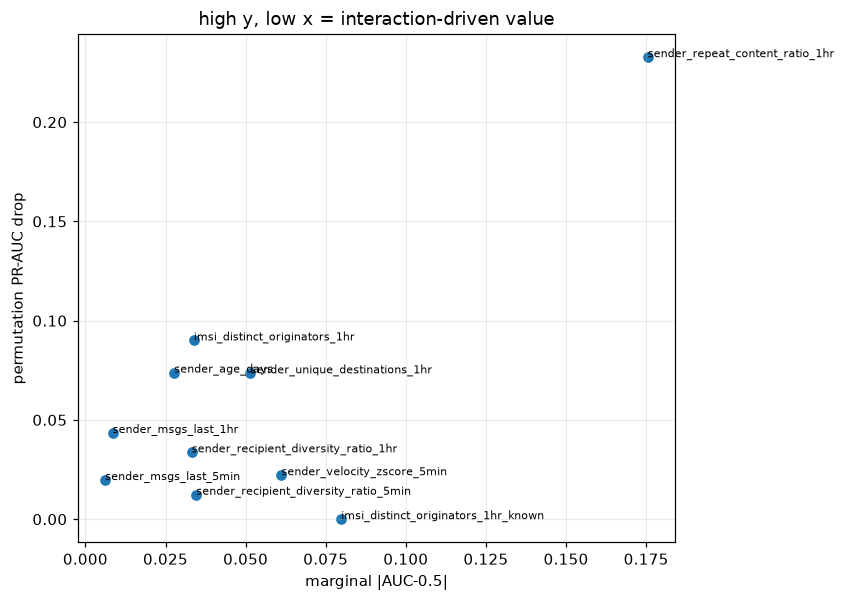

In [10]:
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score
if y.nunique() == 2:
    # LightGBM's real behavioural inputs only (raw ratios, no gated/bucketed/entropy)
    base = lab[[c for c in BEHAVIORAL_COLS + [IMSI_DISTINCT_ORIG_COL, IMSI_DISTINCT_ORIG_COL + "_known", SENDER_VELOCITY_ZSCORE_COL] if c in lab.columns and c not in dead]]
    grp = M.loc[lab_mask, "originator"].fillna("na").to_numpy(); yy = y.astype(int).to_numpy()
    tr, te = next(GroupShuffleSplit(1, test_size=.3, random_state=0).split(base, yy, grp))
    mdl = lgb.LGBMClassifier(n_estimators=250, learning_rate=.08, num_leaves=31, min_child_samples=50,
                             importance_type="gain", verbose=-1).fit(base.iloc[tr], yy[tr])
    ap0 = average_precision_score(yy[te], mdl.predict_proba(base.iloc[te])[:, 1]); print(f"holdout PR-AUC {ap0:.4f}")
    gain = pd.Series(mdl.feature_importances_, base.columns); gain /= gain.sum()
    rng = np.random.default_rng(0); perm = {}
    for c in base.columns:
        d = base.iloc[te].copy(); d[c] = rng.permutation(d[c].to_numpy())
        perm[c] = ap0 - average_precision_score(yy[te], mdl.predict_proba(d)[:, 1])
    marg = {c: abs(roc_auc_score(yy, base[c].fillna(base[c].median())) - .5) for c in base.columns if base[c].nunique() > 1}
    imp = pd.DataFrame({"gain_share": gain, "perm_drop_prAUC": pd.Series(perm), "marginal_auc_dist": pd.Series(marg)}).sort_values("perm_drop_prAUC", ascending=False)
    display(imp.round(4).head(25))
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(imp.marginal_auc_dist, imp.perm_drop_prAUC)
    for c, r in imp.head(12).iterrows(): ax.annotate(c, (r.marginal_auc_dist, r.perm_drop_prAUC), fontsize=7)
    ax.set(xlabel="marginal |AUC-0.5|", ylabel="permutation PR-AUC drop", title="high y, low x = interaction-driven value"); plt.show()

## 10. Drop-one ablation (candidates)
3 originator-grouped splits; differences smaller than the split std are noise - this shows a drop does no *measurable* harm, not that it helps.

,variant,pr_auc,std,delta
0,BASELINE,0.3332,0.0141,0.0000
1,drop sender_msgs_last_5min,0.3355,0.0172,0.0023
2,drop diversity_ratio_5min,0.3357,0.0178,0.0025
3,drop diversity_ratio_1hr,0.3390,0.0206,0.0059
4,drop sender_unique_destinations_1hr,0.3233,0.0166,-0.0098
5,drop imsi_distinct_originators_1hr,0.3052,0.0139,-0.0280


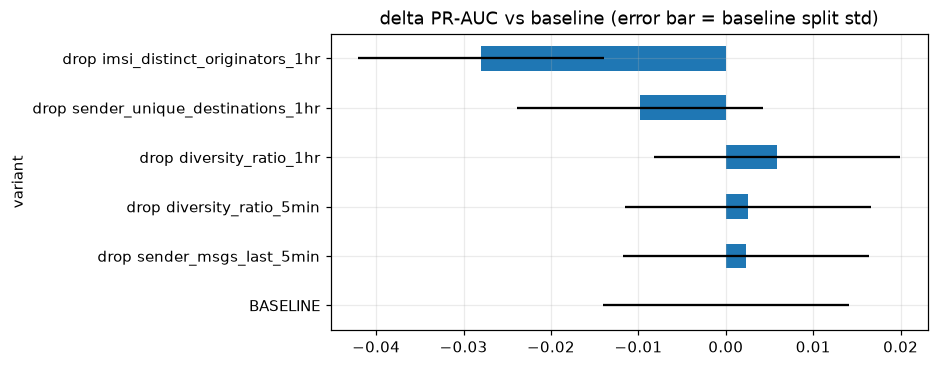

In [11]:
if y.nunique() == 2:
    CANDIDATES = {"sender_msgs_last_5min": ["sender_msgs_last_5min"],
                  "diversity_ratio_5min": ["sender_recipient_diversity_ratio_5min"],
                  "diversity_ratio_1hr": ["sender_recipient_diversity_ratio_1hr"],
                  "sender_unique_destinations_1hr": ["sender_unique_destinations_1hr"],
                  "imsi_distinct_originators_1hr": ["imsi_distinct_originators_1hr", "imsi_distinct_originators_1hr_known"]}
    def cv(cols_):
        aps = []
        for s in range(3):
            a, b = next(GroupShuffleSplit(1, test_size=.3, random_state=s).split(base, yy, grp))
            m = lgb.LGBMClassifier(n_estimators=250, learning_rate=.08, num_leaves=31, min_child_samples=50,
                                   subsample=.8, subsample_freq=1, colsample_bytree=.8, verbose=-1, random_state=s)
            m.fit(base.iloc[a][cols_], yy[a]); aps.append(average_precision_score(yy[b], m.predict_proba(base.iloc[b][cols_])[:, 1]))
        return np.mean(aps), np.std(aps)
    b0 = cv(list(base.columns)); rows = [("BASELINE", *b0, 0.0)]
    for n, d in CANDIDATES.items():
        d = [c for c in d if c in base.columns]; m_, s_ = cv([c for c in base.columns if c not in d]); rows.append((f"drop {n}", m_, s_, m_ - b0[0]))
    res = pd.DataFrame(rows, columns=["variant", "pr_auc", "std", "delta"]); display(res.round(4))
    ax = res.set_index("variant")["delta"].plot.barh(figsize=(7, 3.5), xerr=b0[1]); ax.set_title("delta PR-AUC vs baseline (error bar = baseline split std)"); plt.show()